In [36]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

Menampilkan Citra Backup

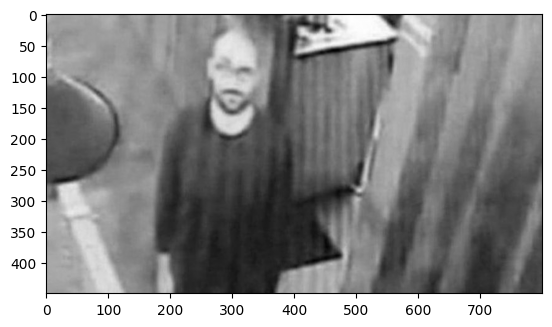

In [37]:
backup = plt.imread('backup.jpg')

backup_gray = cv.cvtColor(backup, cv.COLOR_RGB2GRAY)

plt.imshow(backup_gray, cmap = 'gray')

SMOOTHING, SHARPENING, DAN KOMBINASI KEDUANYA

Perbedaan dari ketiga metode yaitu pada citra yang dihasilkan oleh smoothing, citra tampak lebih mulus dan halus, metode ini dilakukan dengan menyamakan nilai-nilai piksel dengan piksel-piksel yang ada di sekitarnya, namun ketajaman tepi objek dapat menurun. Sedangkan dengan sharpening, citra tampak lebih tajam dibanding dengan smoothing, tepi dan detail citra di pertegas sehingga objek dalam citra akan terlihat lebih jelas dan tepi lebih tegas. Sedangkan gabungan keduanya menghasilkan hasil citra yang buram namun lebih tajam dari pada hasil smoothing saja, hal ini terjadi karena citra terlebih dahulu akan diperhalus untuk meredam noise atau cacat, kemudian ditajamkan agar detailnya kembali terlihat

Perbedaan mean, median dan modus yaitu mean digunakan untuk melakukan bluring dimana bekerja dengan menghitung nilai rata-rata seluruh piksel dalam area kernel sehingga citra yang dihasilkan akan menjadi blur secara merata, namun kurang tahan terhadap noise yang ekstrem. Sedangkan median digunakan untuk menghilangkan noise yang efektif, dimana bekerja dengan mengurutkan seluruh nilai piksel dalam kernel lalu mengambil nilai tengah nya, metode ini sangat efektif dalam menghilangkan noise jenis salt-and-pepper. Sedangkan modus digunakan jika ingin membuat warna dominan menjadi lebih merata, cara kerjanya dengan mengambil nilai piksel yang kemunculannya paling sering dalam kernel, cocok untuk menyederhanakan tampilan region warna tertentu, namun kurang efektif jika akan digunakan untuk menghilangkan noise.

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

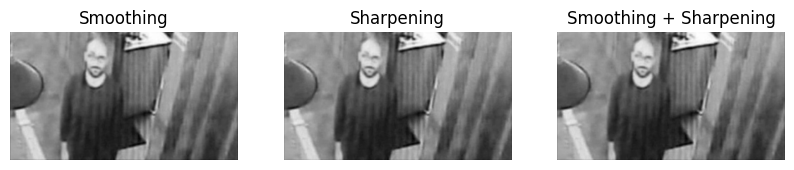

In [38]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img. shape
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5, 1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np. array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

smoothing = convolution(backup_gray, kernelSmoothing)
sharpening = convolution(backup_gray, kernelSharpening)
kombinasi = smoothing + sharpening

plt.figure(figsize=(10, 10))

plt.subplot(1, 3, 1)
plt.imshow(smoothing, cmap='gray')
plt.title("Smoothing")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sharpening, cmap='gray')
plt.title("Sharpening")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(kombinasi, cmap='gray')
plt.title("Smoothing + Sharpening")
plt.axis("off")

DETEKSI TEPI DAN KOMBINASI OPERATOR

Operator-operator digunakan untuk mendeteksi tepi pada citra contoh nya seperti operator prewitt yang dapat digunakan untuk mendeteksi tepi citra dengan cara menghitung perubahan nilai intensitas piksel pada arah horizontal dan vertikal dengan menggunakan kernel dengan bobot yang seragam, cukup baik dalam mendeteksi perubahan intensitas yang halus dan cocok diterapkan pada citra dengan sedikit noise.

Sedangkan operator sobel memiliki prinsip kerja yang hampir sama dengan operator prewitt, namun pada sobel memberikan bobot lebih besar pada piksel di bagian tengah kernel nya. Sehingga sobel akan lebih peka terhadap tepi yang tajam serta menghasilkan deteksi tepi yang lebih jelas dan stabil. Sedangkan operator roberts menggunakan kernel berukuran 2×2 berbeda dengan prewitt dan sobel. dimana roberts bekerja dengan mendeteksi perubahan intensitas secara diagonal. Proses komputasinya lebih cepat, tetapi operator ini sangat sensitif terhadap noise, sehingga roberts cocok digunakan pada citra dengan kualitas baik dan noise yang rendah.

Sedangkan kombinasi operator menghasilkan deteksi citra yang lebih jelas dibanding yang menggunakan satu operator saja. Seperti pada kombinasi prewitt dan sobel yang mampu menghasilkan deteksi tepi yang lebih lengkap karena keduanya sama-sama efektif dalam mendeteksi tepi horizontal dan vertikal. Penggabungan kedua operator tersebut membuat garis tepi menjadi lebih kuat, tebal, dan mudah terlihat.

Berbeda dengan kombinasi prewitt dan roberts, dimana dengan kemampuan prewitt dalam mendeteksi tepi halus dan roberts dalam mendeteksi tepi diagonal akan menghasilkan deteksi menjadi lebih beragam karena dapat menangkap tepi horizontal, vertikal, dan diagonal. Pada kombinasi sobel dan roberts menghasilkan tepi yang lebih tajam dan detail, dimana sobel memberikan hasil deteksi yang akurat, sedangkan roberts menambahkan pada bagian diagonal. Kemudian pada kombinasi prewitt, sobel, dan roberts sekaligus menghasilkan deteksi tepi sempurna karena ketiga operator saling melengkapi dalam mendeteksi berbagai arah tepi. Tepi horizontal, vertikal, maupun diagonal dapat terlihat lebih detail, akan tetapi noise juga akan ikut meningkat.

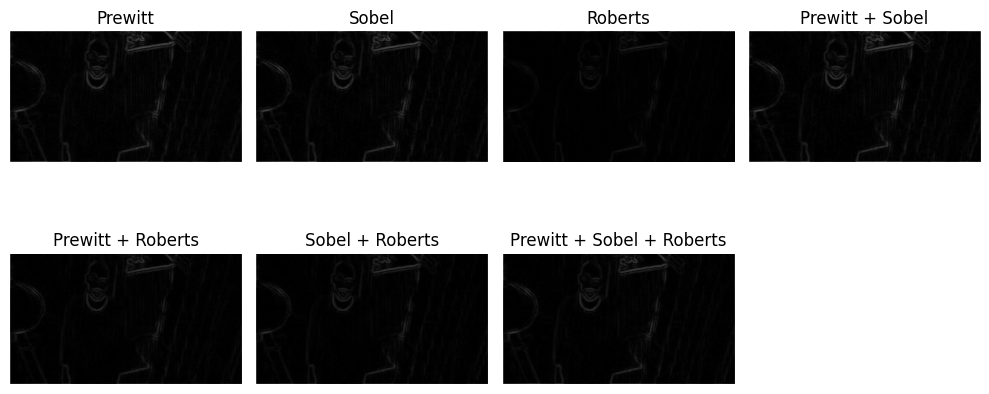

In [39]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np. zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

def normalisasi(image):
    img = image.astype(float)
    return (img - img.min()) / (img.max() - img.min())

sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np.array([
    [ 1, 2, 1],
    [ 0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)


prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np. float32)

prewittY = np.array([
    [ 1, 1, 1],
    [ 0, 0, 0],
    [-1, -1, -1]
], dtype=np. float32)


robertsX = np.array([
    [ 1, 0],
    [ 0, -1]
], dtype=np.float32)

robertsY = np.array([
    [ 0, 1],
    [ -1, 0]
], dtype=np. float32)

prewitt = edge(backup_gray, prewittX, prewittY)
sobel = edge(backup_gray, sobelX, sobelY)
roberts = edge(backup_gray, robertsX, robertsY)

prewitt_norma = normalisasi(prewitt)
sobel_norma = normalisasi(sobel)
roberts_norma = normalisasi(roberts)

preSo = prewitt_norma + sobel_norma
preRo = prewitt_norma + roberts_norma
soRo = sobel_norma + roberts_norma
preSoRo = prewitt_norma + sobel_norma + roberts_norma

plt.figure(figsize=(10, 5))

plt.subplot(2, 4, 1)
plt.imshow(prewitt_norma, cmap = 'gray')
plt.title("Prewitt")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.imshow(sobel_norma, cmap = 'gray')
plt.title("Sobel")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.imshow(roberts_norma, cmap = 'gray')
plt.title("Roberts")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.imshow(preSo, cmap = 'gray')
plt.title("Prewitt + Sobel")
plt.axis("off")

plt.subplot(2, 4, 5)
plt.imshow(preRo, cmap = 'gray')
plt.title("Prewitt + Roberts")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.imshow(soRo, cmap = 'gray')
plt.title("Sobel + Roberts")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.imshow(preSoRo, cmap = 'gray')
plt.title("Prewitt + Sobel + Roberts")
plt.axis("off")

plt.tight_layout()
plt.show()

PERBANDINGAN THRESHOLD TEPI

Penggunaan threshold membuat tepi citra menjadi lebih terlihat dengan jelas, mengetahui setiap tepi yang terlihat berdasarkan nilai ambang yang di tentukan. Penggunaan threshold yaitu dengan mengubah hasil deteksi tepi menjadi citra biner dengan dua nilai yakni hitam dan putih. Piksel dengan nilai lebih besar dari threshold akan dianggap sebagai tepi dan diubah menjadi putih, sedangkan piksel lainnya menjadi hitam. Seperti pada hasil citra dengan threshold 10 dan 20 terlihat lebih banyak tepi terdeteksi, tetapi juga menyebabkan noise dan tekstur background ikut muncul sehingga citra terlihat numpuk. Sebaliknya, threshold tinggi seperti 50 dan 60 menghasilkan citra yang lebih bersih karena noise berkurang, namun banyak detail tepi objek ikut hilang. Sedangkan pada threshold 30 dan 40 mampu menyeimbangkan antara detail objek dan pengurangan noise. Nilai ini masih mempertahankan bentuk objek dengan cukup jelas walaupun ada beberapa detail yang hilang namun dapat terlihat dengan sedikit gangguan dari background.

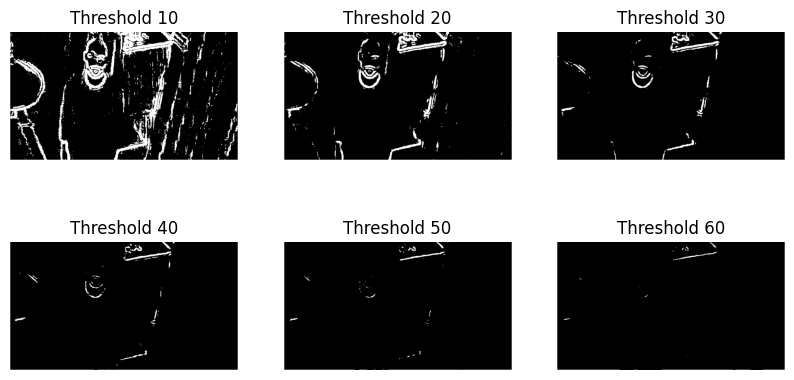

In [40]:
def threshold(img, thres):
    return (img > thres).astype(np.uint8)*255

plt.figure(figsize=(10,5))

thres10 = threshold(prewitt, 10)
thres20 = threshold(prewitt, 20)
thres30 = threshold(prewitt, 30)
thres40 = threshold(prewitt, 40)
thres50 = threshold(prewitt, 50)
thres60 = threshold(prewitt, 60)

plt.subplot(2,3,1)
plt.imshow(thres10, cmap='gray')
plt.title("Threshold 10")
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(thres20, cmap='gray')
plt.title("Threshold 20")
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(thres30, cmap='gray')
plt.title("Threshold 30")
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(thres40, cmap='gray')
plt.title("Threshold 40")
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(thres50, cmap='gray')
plt.title("Threshold 50")
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(thres60, cmap='gray')
plt.title("Threshold 60")
plt.axis('off')

plt.show()

HIGHLIGHT SILUET ORANG

Fungsi Sliding Window (Filter mean, median, modus) Untuk Proses Highlight Siluet Orang

In [41]:
def filter_case(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)

    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total = 0
                    for val in region.ravel():
                        total += int(val)
                    fungsi_mean = total // area
                    canvas[i, j] = fungsi_mean
        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = []
                    for val in region.ravel():
                        values.append(val)
                    values.sort()
                    mid = len(values) // 2
                    fungsi_median = values[mid]
                    canvas[i, j] = fungsi_median
        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val

                    canvas[i, j] = mode_val
    return canvas

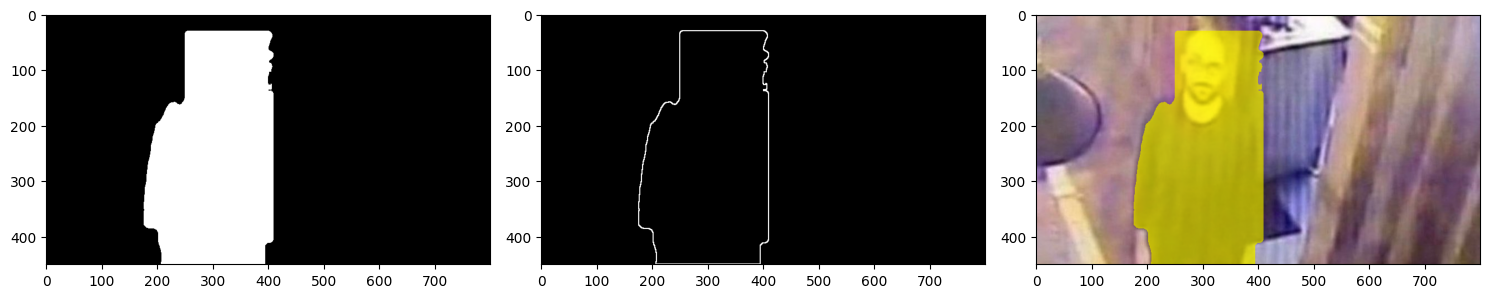

In [42]:
height, width = backup.shape[:2]

masking = np.zeros((height, width), dtype=np.uint8)
for i in range(height):
    for j in range(160, 410):
        masking[i, j] = 255

for i in range(250):
    for j in range(160, 210):
        r = int(backup[i, j, 0])
        g = int(backup[i, j, 1])
        b = int(backup[i, j, 2])
        if (r + g + b) // 3 < 70:
            masking[i, j] = 0

for i in range(height):
    for j in range(350, 410):
        r = int(backup[i, j, 0])
        g = int(backup[i, j, 1])
        b = int(backup[i, j, 2])
        rata = (r + g + b) // 3
        if rata > 130:
            masking[i, j] = 0

for i in range(10, 180):
    for j in range(230, 390):
        masking[i, j] = 255

for i in range(180, height):
    for j in range(185, 395):
        gray_val = int(backup_gray[i, j])
        if gray_val < 180:
            masking[i, j] = 255

for i in range(height):
    for j in range(160, 250):
        gray_val = int(backup_gray[i, j])
        if gray_val > 104:
            masking[i, j] = 0

for i in range(0, 150):
    for j in range(160, 240):
        r = int(backup[i, j, 0])
        g = int(backup[i, j, 1])
        b = int(backup[i, j, 2])
        if not (r > 100 and r > g + 10 and r > b + 10):
            masking[i, j] = 0

for i in range(0, 30):
    for j in range(width):
        masking[i, j] = 0


masking = filter_case(masking, 9, 'median')
masking = threshold(masking, 50)

edge_citra = edge(masking, sobelX, sobelY)
edge_citra = threshold(edge_citra, 30)

#Highlight Kuning
highlight = np.zeros((height, width, 3), dtype=np.uint8)
for i in range(height):
    for j in range(width):
        r = int(backup[i, j, 0])
        g = int(backup[i, j, 1])
        b = int(backup[i, j, 2])
        if masking[i, j] == 255:
            nr = r * 4 // 10 + 255 * 6 // 10
            ng = g * 4 // 10 + 255 * 6 // 10
            nb = b * 15 // 100
            if nr > 255:
                nr = 255
            highlight[i, j, 0] = nr
            highlight[i, j, 1] = ng
            highlight[i, j, 2] = nb
        else:
            highlight[i, j, 0] = r
            highlight[i, j, 1] = g
            highlight[i, j, 2] = b

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(masking, cmap='gray')

plt.subplot(1, 3, 2)
plt.imshow(edge_citra, cmap='gray')

plt.subplot(1, 3, 3)
plt.imshow(highlight)

plt.tight_layout()
plt.show()

DETEKSI TEPI DAN BACKGROUND REMOVAL

Proses dimulai dengan membaca citra yang akan di deteksi yaitu david.jpg dengan menggunakan plt.imread(). Setelah citra berhasil dibaca, program mengambil ukuran gambar berupa tinggi, lebar, dan jumlah channel warna RGB. Selanjutnya dilakukan proses konversi citra berwarna menjadi grayscale dengan cara menghitung rata-rata nilai merah (R), hijau (G), dan biru (B) pada setiap piksel. Kemudian hasil grayscale akan digunakan untuk mempermudah proses deteksi tepi karena hanya memiliki satu nilai intensitas pada setiap piksel.

Setelah itu dilakukan proses deteksi tepi, dimana program menghitung perbedaan intensitas antar piksel secara horizontal (gx) dan vertikal (gy). Nilai keduanya dijumlahkan menjadi total. Jika nilai total lebih besar dari threshold 30, maka piksel dianggap sebagai tepi dan diberi nilai putih (255). Jika tidak, piksel diberi nilai hitam (0). Hasil proses ini menghasilkan citra tepi yang menampilkan garis luar kepala dan pakaian objek.

Langkah selanjutnya yaitu pembuatan mask background menggunakan perbandingan nilai RGB, dimana program akan memeriksa setiap piksel pada citra asli. Jika nilai hijau (g) dan biru (b) lebih besar daripada merah (r) dengan selisih lebih dari 30, maka piksel dianggap sebagai background berwarna toska dan diberi nilai hitam (0). Begitu juga sebaliknya, piksel yang bukan background akan dianggap sebagai objek utama dan diberi nilai putih (255). Hasil tahap ini berupa mask biner yang memisahkan objek dan latar belakang.

Pada proses background removal, dibuat citra baru bernama hasil, dimana apabila nilai mask bernilai 255, maka piksel asli dari citra david dipertahankan. Sebaliknya, apabila mask bernilai 0, maka piksel diubah menjadi putih atau 255. Dengan begitu background berhasil dihilangkan sementara objek utama tetap terlihat.

Hasil akhir menampilkan tiga tahapan utama, yaitu citra deteksi tepi, mask background, dan citra hasil background removal.


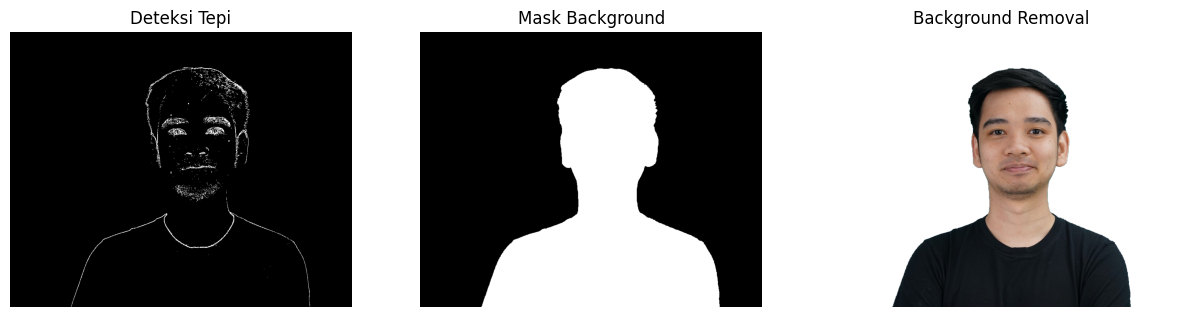

In [43]:
david = plt.imread('david.jpg')

height, width, channel = david.shape
david_gray = np.zeros((height, width), dtype=np.uint8)

for i in range(height):
    for j in range(width):
        r = int(david[i, j, 0])
        g = int(david[i, j, 1])
        b = int(david[i, j, 2])
        gray_val = (r + g + b) // 3
        david_gray[i, j] = gray_val
edge = np.zeros((height, width), dtype=np.uint8)

for i in range(height - 1):
    for j in range(width - 1):
        gx = abs(int(david_gray[i, j]) - int(david_gray[i, j+1]))
        gy = abs(int(david_gray[i, j]) - int(david_gray[i+1, j]))
        total = gx + gy
        if total > 30:
            edge[i, j] = 255
        else:
            edge[i, j] = 0
mask = np.zeros((height, width), dtype=np.uint8)

for i in range(height):
    for j in range(width):
        r = int(david[i, j, 0])
        g = int(david[i, j, 1])
        b = int(david[i, j, 2])
        if g > r + 30 and b > r + 30:
            mask[i, j] = 0
        else:
            mask[i, j] = 255
hasil = np.zeros((height, width, 3), dtype=np.uint8)

for i in range(height):
    for j in range(width):
        if mask[i, j] == 255:
            hasil[i, j, 0] = david[i, j, 0]
            hasil[i, j, 1] = david[i, j, 1]
            hasil[i, j, 2] = david[i, j, 2]
        else:
            hasil[i, j] = [255,255,255]

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(edge, cmap='gray')
plt.title('Deteksi Tepi')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title('Mask Background')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(hasil)
plt.title('Background Removal')
plt.axis('off')

plt.show()

Analisis dan Kesimpulan

Berdasarkan praktikum yang telah dilakukan, dapat disimpulkan bahwa perbaikan kualitas citra dan deteksi tepi merupakan bagian yang penting dan sangat dibutuhkan dalam pengolahan citra digital. Dimana perbaikan kualitas citra dapat digunakan untuk memperjelas tampilan citra, mengurangi noise, memperjelas dan meningkatkan detail, serta membantu proses analisis agar lebih mudah untuk dilakukan. Dengan kualitas gambar yang lebih baik, objek pada citra menjadi lebih mudah dikenali dan diolah. Sedangkan deteksi tepi dapat digunakan untuk mendeteksi batas objek melalui perubahan intensitas piksel. Proses ini membantu dalam mengenali bentuk objek, memisahkan objek dari background atau latar belakang, serta mendukung proses segmentasi dan penghilangan background. Operator-operator seperti prewitt, sobel, dan roberts memiliki kemampuan yang berbeda sehingga menghasilkan karakteristik deteksi tepi yang berbeda juga. Selain itu, threshold dan mask digunakan untuk memisahkan foreground dan background dengan lebih jelas. Gabungan teknik perbaikan kualitas citra, deteksi tepi, thresholding, dan masking membuat proses untuk mengidentifikasi objek menjadi lebih efektif dan akurat. Sehingga teknik-teknik ini banyak diterapkan dalam berbagai bidang pengolahan citra digital, seperti pengenalan wajah, computer vision, sistem keamanan, dan lainnya.